# Train Neural Network with PyTorch

In [6]:
!pip install torch
!pip install torchvision
!pip install tqdm
!pip install matplotlib
!pip install --upgrade "numpy<2"

### 1. Load libraries

In [7]:
import torch
import torchvision
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import Compose, ToTensor, Lambda
from tqdm import tqdm

print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

Torch version: 2.11.0+cu130
Torchvision version: 0.26.0+cu130


### GPU availibility

In [14]:
def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available else "cpu")

def move_to_device(tensor: torch.Tensor, device: torch.device) -> torch.Tensor:
    return tensor.to(device)

device = get_device()
print("Using device: ", device)

Using device:  cuda


### 2. Construct neural network

In [15]:
model = nn.Sequential(
    nn.Linear(784, 512),
    nn.ReLU(),
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)

loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(params=model.parameters(), lr=0.001)


def forward(input_images: torch.Tensor):
    return model(input_images)

def predict(input_images: torch.Tensor):
    # only doing inference here, not training, so don’t build the gradient computation graph
    with torch.no_grad():
        logits = forward(input_images)
        predicted_labels = torch.argmax(logits, dim=-1)
        return predicted_labels

def train_on_batch(batch_images: torch.Tensor, batch_labels: torch.Tensor):
    # Run the model on one batch of images
    logits = forward(batch_images)

    # Compute prediction error for this batch
    loss = loss_function(logits, batch_labels)

    # Clear gradients from previous step
    optimizer.zero_grad()

    # Compute gradients by backpropagation
    loss.backward()

    # Update model parameters
    optimizer.step()

    # Return loss as a regular Python number
    return loss.item()



### 3. Prepare dataset

In [16]:
mnist_transform = Compose([
    ToTensor(), #preprocess each record to torch tensor
    Lambda(lambda image: image.view(784)) #flatten each record
])

train_dataset = MNIST(
    root="./",
    train=True,
    download=True,
    transform=mnist_transform
)

test_dataset = MNIST(
    root="./",
    train=False,
    download=True,
    transform=mnist_transform
)

print("First training sample: ", train_dataset[0][0])
print("First test sample: ", test_dataset[0][0])


First training sample:  tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 

Label: 5
Shape before reshape: torch.Size([784])


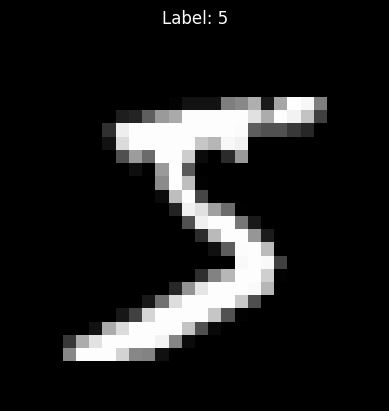

In [17]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

print("Label:", label)
print("Shape before reshape:", image.shape)   # torch.Size([784])

plt.imshow(image.view(28, 28), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

### 4. Train network

In [18]:
# Load data in small batches, which makes training more convenient
# and avoids processing the whole dataset at once

batch = 16
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch,
    shuffle=False
)

# Train the model for a fixed number of epochs - training is iterative procedure

num_epochs = 5

for epoch_index in range(num_epochs):
    model.train()
    total_epoch_loss = 0.0

    for batch_images, batch_labels in tqdm(train_loader, desc=f"Training epoch {epoch_index + 1}/{num_epochs}"):
        loss = train_on_batch(batch_images, batch_labels)
        total_epoch_loss += loss

    average_epoch_loss = total_epoch_loss / len(train_loader)
    print(f"Epoch {epoch_index + 1}/{num_epochs} - Average loss: {average_epoch_loss:.4f}")

model.eval()
correct_predictions = 0
total_predictions = 0


Training epoch 1/5: 100%|██████████| 3750/3750 [00:30<00:00, 121.05it/s]


Epoch 1/5 - Average loss: 0.2176


Training epoch 2/5: 100%|██████████| 3750/3750 [00:29<00:00, 127.30it/s]


Epoch 2/5 - Average loss: 0.1010


Training epoch 3/5: 100%|██████████| 3750/3750 [00:28<00:00, 130.14it/s]


Epoch 3/5 - Average loss: 0.0741


Training epoch 4/5: 100%|██████████| 3750/3750 [00:28<00:00, 133.06it/s]


Epoch 4/5 - Average loss: 0.0594


Training epoch 5/5: 100%|██████████| 3750/3750 [00:30<00:00, 122.59it/s]

Epoch 5/5 - Average loss: 0.0488


### 5. Use trained network

In [12]:
for batch_images, batch_labels in test_loader:
    predicted_labels = predict(batch_images)
    correct_predictions += (predicted_labels == batch_labels).sum().item()
    total_predictions += len(batch_labels)

test_accuracy = correct_predictions / total_predictions
print(f"Test accuracy: {test_accuracy:.4f}")

Test accuracy: 0.9742
